# Simple model

We simulate bursts with N=1 component and infer one parameter, the peak time (`t0`) with MCMC and normalizing flows.

In [1]:
import sys
sys.path.append('..')

import emcee
import numpy as np
import math 
import matplotlib.pyplot as plt
from typing import Iterable

from src.helpers import twoexp, combined_twoexp, simulate_burst, plot_simulated_burst, plot_trace

In [9]:
time = np.linspace(0, 1.0, 1000)
N = 1
amp = 10.0
t0 = 0.4
rise = 0.03
skew = 5.0

ybkg = 5.0

x_model, x_counts = simulate_burst(
    time=time,
    ncomp=N,
    burstparams=[t0, amp, rise, skew],
    ybkg=ybkg,
    return_model=True
)

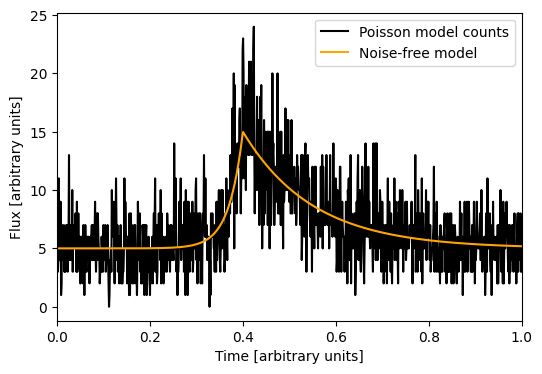

In [10]:
plot_simulated_burst(time, x_counts, x_model)
plt.show()

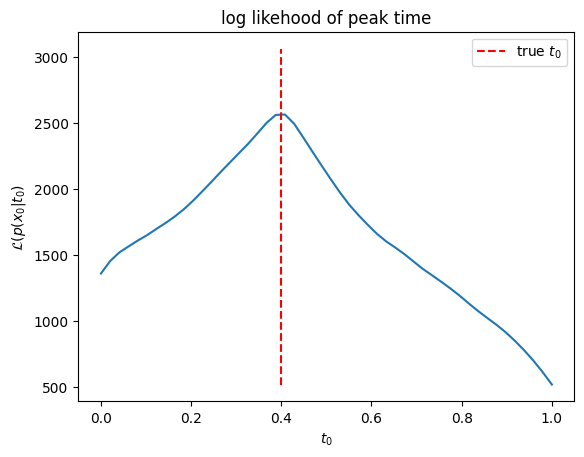

In [11]:
def log_likelihood(t0: float, x_counts: Iterable[int]) -> float:
    """
    $ln(p(x_{counts} | t0)$
    natural logarithm of poisson likelihood.
    """
    
    L = 0
    # true rate 
    model_counts = combined_twoexp(time, [t0], [amp], [rise], [skew], ybkg)

    L = (
        -1 * np.sum(np.log(model_counts)) 
        + np.sum(x_counts * np.log(model_counts)) 
        - np.sum([math.log(math.factorial(x)) for x in x_counts]) # Note x is simulated count and should always be integer
    )
    
    # TODO: Compare w/ likelihood function of Daniela
    return L

true_t0 = t0
t0s = np.linspace(0, 1, 50)
likelihoods = [log_likelihood(t0, x_counts) for t0 in t0s]
plt.plot(t0s, likelihoods)
plt.title("log likehood of peak time")
plt.ylabel("$\mathcal{L}(p(x_0 | t_0)$")
plt.xlabel("$t_0$")
plt.vlines([true_t0],  ymin=min(likelihoods), ymax=max(likelihoods) + 500, linestyles="dashed", color ='red', label='true $t_0$')
plt.legend()
plt.show()


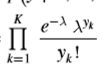

In [12]:
nwalkers = 20
ndim = 1
p0 = np.random.rand(nwalkers, ndim) # initial position of the walkers

def log_prob(t0: Iterable[float], *args) -> float:
    """
    Log of the posterior distribution.
    """
    # t0 is bounded by the uniform prior
    if t0 < 0 or t0 > 1:
        return -np.inf
    
    # otherwise its equal to the likelihood
    return log_likelihood(t0, *args)

# https://emcee.readthedocs.io/en/stable/tutorials/quickstart/
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=[x_counts])

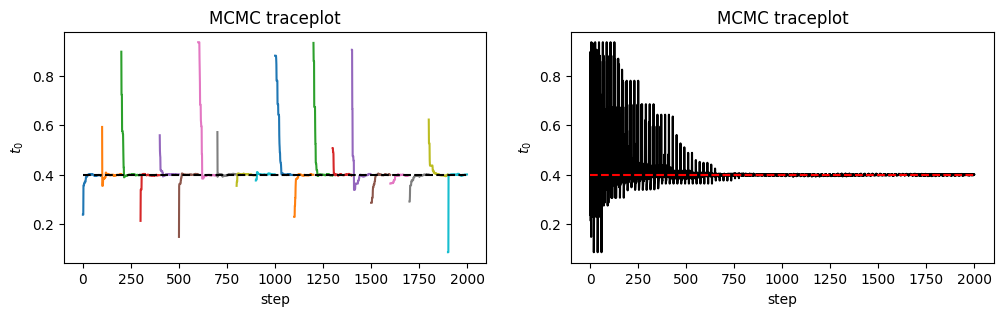

In [13]:
# burn-in 
burn_steps = 100
state = sampler.run_mcmc(p0, burn_steps)
plot_trace(sampler, burn_steps, true_t0)
sampler.reset()

In [14]:
steps = 1000
sampler.run_mcmc(state, 1000)

State([[0.40076847]
 [0.39939958]
 [0.39785058]
 [0.40084478]
 [0.39800319]
 [0.40173124]
 [0.39959438]
 [0.40391481]
 [0.39923155]
 [0.39773681]
 [0.40121567]
 [0.39813683]
 [0.39994883]
 [0.39938861]
 [0.39827708]
 [0.40177916]
 [0.39836396]
 [0.3972661 ]
 [0.39886166]
 [0.3999394 ]], log_prob=[2568.41973957 2568.6294996  2568.04367947 2568.38614847 2568.10750789
 2567.91372482 2568.60810467 2566.07327453 2568.55982936 2567.99896294
 2568.23935861 2568.16700931 2568.58811858 2568.62488222 2568.23308531
 2567.87743825 2568.27588064 2567.79796383 2568.42515239 2568.58833379], blobs=None, random_state=('MT19937', array([3670154431, 3197447340, 4139593642,  409832187, 1673493727,
       4051535574,   78084515, 1339978878, 1880660065, 4145503812,
       1538491025, 4255120749, 3696974776, 3482258923, 3766517103,
       1235859271, 1658651131, 1373925449, 1139956592,  324003756,
       1648735069, 3564980536, 1756366201, 4070234843,  682715941,
        959862456, 1683796273, 3627664131, 22

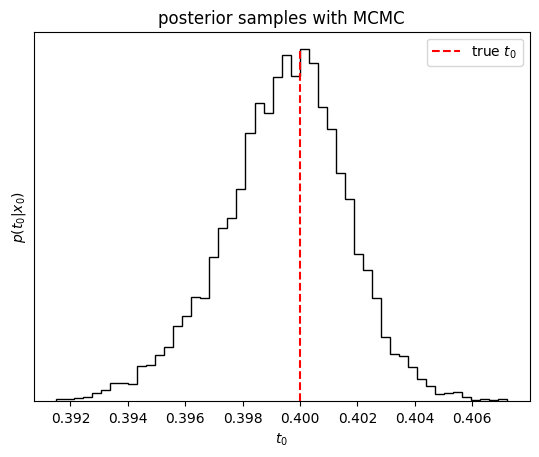

In [15]:
samples = sampler.get_chain(flat=True)

frequencies, _, _ = plt.hist(samples[:, 0], 50, color="k", histtype="step")
plt.vlines([true_t0],  ymin=0, ymax=max(frequencies), linestyles="dashed", color ='red', label='true $t_0$')

plt.title("posterior samples with MCMC")
plt.xlabel("$t_0$")
plt.ylabel("$p(t_0 | x_0)$")
plt.gca().set_yticks([])

plt.legend()
plt.show()

In [16]:
print(
    "Mean acceptance fraction: {0:.3f}".format(
        np.mean(sampler.acceptance_fraction)
    )
)

# TODO: Diagnose mcmc Trace plots chains as a func of iteration (ideally should be white noise)
# Autocorrelation time check
# add plots where you overlay samples from the posterior on the data

Mean acceptance fraction: 0.796


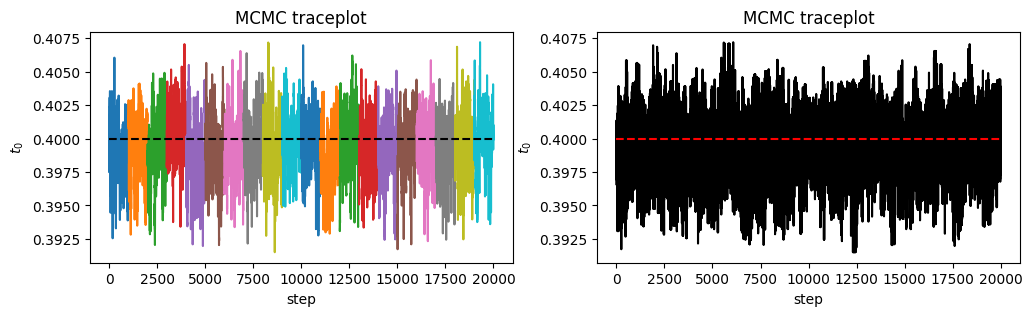

In [17]:
# trace plot
plot_trace(sampler, steps, true_t0)
plt.show()

# Two peaks

In [73]:
time = np.linspace(0, 1, 1000)
N = 2
amp = 16.0
t0 = 0.1
rise = 0.03
skew = 5.0

ybkg = 5.0

t0_l = [t0, t0+0.5]
rise_l = [rise, rise]
amp_l = [amp, amp] 
skew_l = [skew, skew] 

burstparams = np.array([t0_l, amp_l, rise_l, skew_l]).flatten()

x_model, x_counts = simulate_burst(
    time=time,
    ncomp=N,
    burstparams=burstparams,
    ybkg=ybkg,
    return_model=True
)

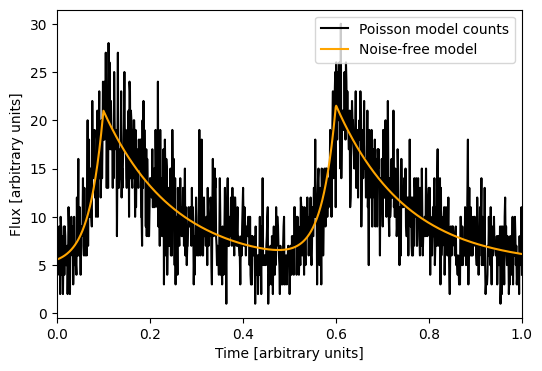

In [74]:
plot_simulated_burst(time, x_counts, x_model)
plt.show()

In [75]:
nwalkers = 20
ndim = 2
p0 = np.random.rand(nwalkers, ndim) # initial position of the walkers

def log_likelihood(t0, x_counts):
    """
    $ln(p(x_{counts} | t0)$
    natural logarithm of poisson likelihood.
    """
    
    L = 0
    # true rate 
    model_counts = combined_twoexp(time, t0, [amp, amp], [rise, rise], [skew, skew], ybkg)

    L = (
        -1 * np.sum(np.log(model_counts)) 
        + np.sum(x_counts * np.log(model_counts)) 
        - np.sum([math.log(math.factorial(x)) for x in x_counts]) # TODO: If x is float, change m.factorial(x), m.gamma(x + 1)
    )
    
    # TODO: Compare w/ likelihood function of Daniela
    return L

is_sorted = lambda a: np.all(a[:-1] <= a[1:])

def log_prob(t0, *args):
    """
    Log of the posterior distribution.
    """
    # t0 is bounded by the uniform prior
    if t0.any() < 0 or t0.any() > 1:
        return -np.inf
        
    # peak time of first peak should be smaller than second peak etc. etc.
    # if len(t0) > 1 and not is_sorted(t0):
    #     return -np.inf
    
    # otherwise its equal to the likelihood
    return log_likelihood(t0, *args)

# https://emcee.readthedocs.io/en/stable/tutorials/quickstart/
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=[x_counts])

In [76]:
# burn-in of 100 steps
state = sampler.run_mcmc(p0, 300)
sampler.reset()
sampler.run_mcmc(state, 2000)

State([[0.60093396 0.09765562]
 [0.09855887 0.59973992]
 [0.59821804 0.0989591 ]
 [0.10167405 0.59947237]
 [0.59451144 0.10015639]
 [0.59822783 0.10163812]
 [0.09771832 0.59813666]
 [0.09951574 0.5994661 ]
 [0.1005292  0.59837029]
 [0.1005043  0.59606701]
 [0.10079493 0.59559365]
 [0.60043768 0.09733877]
 [0.0993106  0.59804011]
 [0.10028058 0.5986574 ]
 [0.5997331  0.10163951]
 [0.10223015 0.59944744]
 [0.59715945 0.09934218]
 [0.09493299 0.59957667]
 [0.59743808 0.09996548]
 [0.59772939 0.09853102]], log_prob=[5702.98754922 5703.99117007 5704.41881541 5703.34250949 5701.92520644
 5703.54714008 5703.87835801 5704.21471571 5704.20084866 5703.11365782
 5702.66757133 5703.14290743 5704.40557722 5704.34108267 5703.28693404
 5702.91392631 5704.09139882 5701.26062147 5704.19270597 5704.20384905], blobs=None, random_state=('MT19937', array([2768118129,  129629232, 3461551243, 3949340158, 1962602651,
       3947727839, 3541424812, 1364628605, 3505041476,  654370226,
       3769107389, 2429371

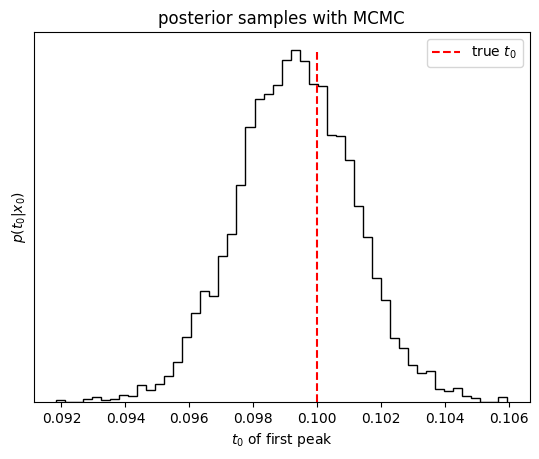

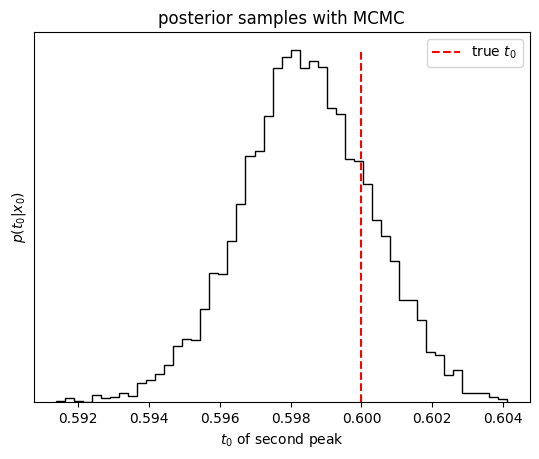

array([[0.10337497, 0.59698601],
       [0.10064161, 0.59636037],
       [0.10138985, 0.59823765],
       ...,
       [0.09493299, 0.59957667],
       [0.09996548, 0.59743808],
       [0.09853102, 0.59772939]])

In [77]:
samples = sampler.get_chain(flat=True)

sorted_samples = np.sort(samples, axis=1)

frequencies, _, _ = plt.hist(sorted_samples[:, 0], 50, color="k", histtype="step")
plt.vlines([0.1],  ymin=0, ymax=max(frequencies), linestyles="dashed", color ='red', label='true $t_{0}$')

plt.title("posterior samples with MCMC")
plt.xlabel("$t_0$ of first peak")
plt.ylabel("$p(t_0 | x_0)$")
plt.gca().set_yticks([])

plt.legend()
plt.show()

frequencies, _, _ = plt.hist(sorted_samples[:, 1], 50, color="k", histtype="step")
plt.vlines([0.6],  ymin=0, ymax=max(frequencies), linestyles="dashed", color ='red', label='true $t_{0}$')

plt.title("posterior samples with MCMC")
plt.xlabel("$t_0$ of second peak")
plt.ylabel("$p(t_0 | x_0)$")
plt.gca().set_yticks([])

plt.legend()
plt.show()

samples
sorted_samples

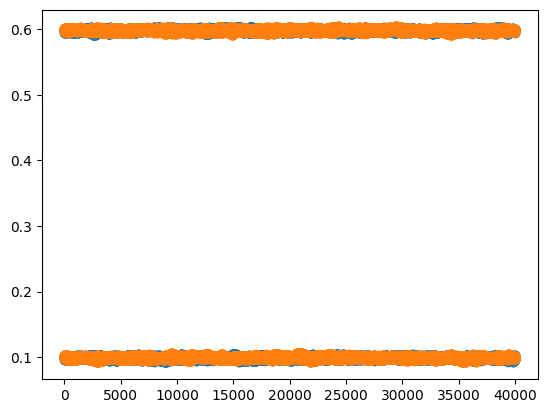

In [78]:
plt.plot(sampler.get_chain(flat=True), 'o')

In [60]:
# Normalizing flow

# generate bunch of training data (all params fixed except t0?)

# generate posterior using normalizing flow ?

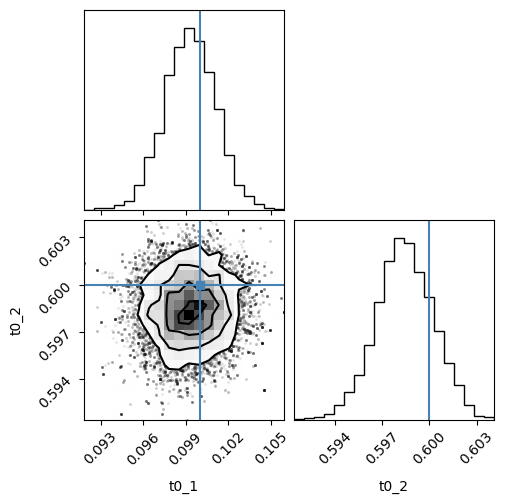

In [79]:
from corner import corner

fig = corner(sorted_samples, labels=["t0_1", "t0_2"], truths=[0.1, 0.6])

In [80]:
tau = sampler.get_autocorr_time()
print(tau)

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [49.33153006 64.55972216]

Text(0.5, 0, 'step number')

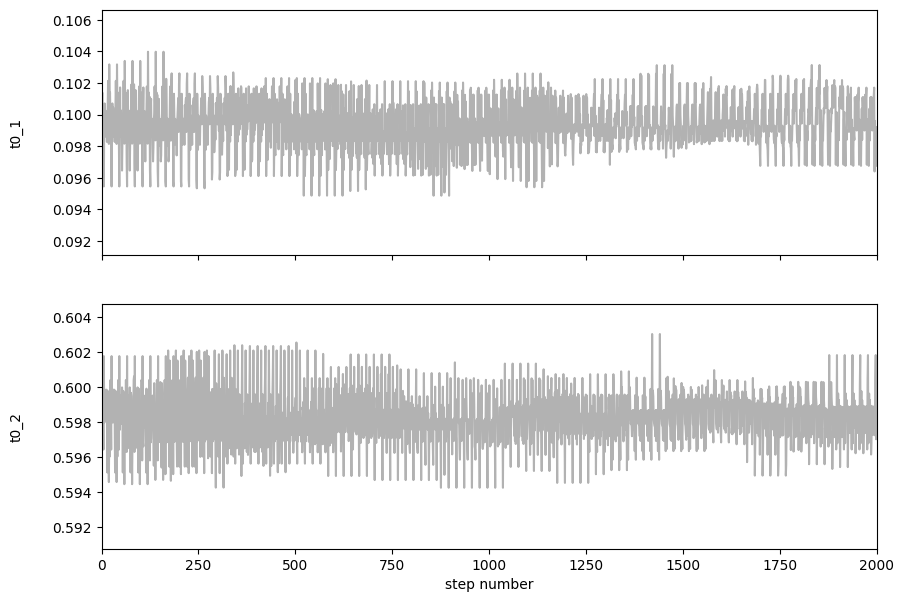

In [85]:
fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
labels = ["t0_1", "t0_2"]
for i in range(2):
    ax = axes[i]
    ax.plot(sorted_samples[:, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")